In [180]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score, roc_curve, auc, brier_score_loss

In [181]:
!pip install lightgbm 

In [182]:
import lightgbm as lgb

Data loading

In [183]:
race_df = pd.read_csv("../data/races.csv", na_values="\\N", parse_dates=["date", "quali_date"])
race_df.head()

,raceId,year,round,circuitId,name,date,time,url,fp1_date,fp1_time,fp2_date,fp2_time,fp3_date,fp3_time,quali_date,quali_time,sprint_date,sprint_time
0,1,2009,1,1,Australian Grand Prix,2009-03-29,06:00:00,http://en.wikipedia.org/wiki/2009_Australian_G...,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN
1,2,2009,2,2,Malaysian Grand Prix,2009-04-05,09:00:00,http://en.wikipedia.org/wiki/2009_Malaysian_Gr...,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN
2,3,2009,3,17,Chinese Grand Prix,2009-04-19,07:00:00,http://en.wikipedia.org/wiki/2009_Chinese_Gran...,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN
3,4,2009,4,3,Bahrain Grand Prix,2009-04-26,12:00:00,http://en.wikipedia.org/wiki/2009_Bahrain_Gran...,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN
4,5,2009,5,4,Spanish Grand Prix,2009-05-10,12:00:00,http://en.wikipedia.org/wiki/2009_Spanish_Gran...,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN


In [184]:
res_df = pd.read_csv("../data/results.csv", na_values="\\N")
res_df.head()

,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId
0,1,18,1,1,22.0,1.0,1.0,1,1,10.0,58,1:34:50.616,5690616.0,39.0,2.0,1:27.452,218.300,1
1,2,18,2,2,3.0,5.0,2.0,2,2,8.0,58,+5.478,5696094.0,41.0,3.0,1:27.739,217.586,1
2,3,18,3,3,7.0,7.0,3.0,3,3,6.0,58,+8.163,5698779.0,41.0,5.0,1:28.090,216.719,1
3,4,18,4,4,5.0,11.0,4.0,4,4,5.0,58,+17.181,5707797.0,58.0,7.0,1:28.603,215.464,1
4,5,18,5,1,23.0,3.0,5.0,5,5,4.0,58,+18.014,5708630.0,43.0,1.0,1:27.418,218.385,1


In [185]:
constructor_df = pd.read_csv("../data/constructors.csv")
constructor_df.head()

,constructorId,constructorRef,name,nationality,url
0,1,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren
1,2,bmw_sauber,BMW Sauber,German,http://en.wikipedia.org/wiki/BMW_Sauber
2,3,williams,Williams,British,http://en.wikipedia.org/wiki/Williams_Grand_Pr...
3,4,renault,Renault,French,http://en.wikipedia.org/wiki/Renault_in_Formul...
4,5,toro_rosso,Toro Rosso,Italian,http://en.wikipedia.org/wiki/Scuderia_Toro_Rosso


In [186]:
drivers_df = pd.read_csv("../data/drivers.csv", na_values="\\N", parse_dates=["dob"])
drivers_df.head()

,driverId,driverRef,number,code,forename,surname,dob,nationality,url
0,1,hamilton,44.0,HAM,Lewis,Hamilton,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton
1,2,heidfeld,NaN,HEI,Nick,Heidfeld,1977-05-10,German,http://en.wikipedia.org/wiki/Nick_Heidfeld
2,3,rosberg,6.0,ROS,Nico,Rosberg,1985-06-27,German,http://en.wikipedia.org/wiki/Nico_Rosberg
3,4,alonso,14.0,ALO,Fernando,Alonso,1981-07-29,Spanish,http://en.wikipedia.org/wiki/Fernando_Alonso
4,5,kovalainen,NaN,KOV,Heikki,Kovalainen,1981-10-19,Finnish,http://en.wikipedia.org/wiki/Heikki_Kovalainen


In [187]:
status_df = pd.read_csv("../data/status.csv", na_values="\\N")
status_df.head()

,statusId,status
0,1,Finished
1,2,Disqualified
2,3,Accident
3,4,Collision
4,5,Engine


Constructing the flat dataset for eval

In [188]:
full_race_data_df = pd.merge(
    left=res_df[["resultId", "raceId","driverId", "constructorId", "position", "statusId"]],
    right=race_df[["raceId","year","round","circuitId","name","date"]],
    on="raceId"
)

full_race_data_df = pd.merge(
    left=full_race_data_df,
    right=drivers_df[["driverId","dob","nationality"]],
    on="driverId"
)

full_race_data_df["podiumFinish"] = (full_race_data_df["position"] <= 3).astype(int)

full_race_data_df

,resultId,raceId,driverId,constructorId,position,statusId,year,round,circuitId,name,date,dob,nationality,podiumFinish
0,1,18,1,1,1.0,1,2008,1,1,Australian Grand Prix,2008-03-16,1985-01-07,British,1
1,2,18,2,2,2.0,1,2008,1,1,Australian Grand Prix,2008-03-16,1977-05-10,German,1
2,3,18,3,3,3.0,1,2008,1,1,Australian Grand Prix,2008-03-16,1985-06-27,German,1
3,4,18,4,4,4.0,1,2008,1,1,Australian Grand Prix,2008-03-16,1981-07-29,Spanish,0
4,5,18,5,1,5.0,1,2008,1,1,Australian Grand Prix,2008-03-16,1981-10-19,Finnish,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27299,27305,1171,4,117,18.0,11,2026,3,22,Japanese Grand Prix,2026-03-29,1981-07-29,Spanish,0
27300,27306,1171,822,216,19.0,11,2026,3,22,Japanese Grand Prix,2026-03-29,1989-08-28,Finnish,0
27301,27307,1171,848,3,20.0,12,2026,3,22,Japanese Grand Prix,2026-03-29,1996-03-23,Thai,0
27302,27308,1171,840,117,21.0,34,2026,3,22,Japanese Grand Prix,2026-03-29,1998-10-29,Canadian,0


In [189]:
training_race_data_df = full_race_data_df[full_race_data_df["year"] < 2025].copy()
training_race_data_df

,resultId,raceId,driverId,constructorId,position,statusId,year,round,circuitId,name,date,dob,nationality,podiumFinish
0,1,18,1,1,1.0,1,2008,1,1,Australian Grand Prix,2008-03-16,1985-01-07,British,1
1,2,18,2,2,2.0,1,2008,1,1,Australian Grand Prix,2008-03-16,1977-05-10,German,1
2,3,18,3,3,3.0,1,2008,1,1,Australian Grand Prix,2008-03-16,1985-06-27,German,1
3,4,18,4,4,4.0,1,2008,1,1,Australian Grand Prix,2008-03-16,1981-07-29,Spanish,0
4,5,18,5,1,5.0,1,2008,1,1,Australian Grand Prix,2008-03-16,1981-10-19,Finnish,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26754,26760,1144,825,210,16.0,11,2024,24,24,Abu Dhabi Grand Prix,2024-12-08,1992-10-05,Danish,0
26755,26761,1144,859,215,17.0,5,2024,24,24,Abu Dhabi Grand Prix,2024-12-08,2002-02-11,New Zealander,0
26756,26762,1144,822,15,NaN,130,2024,24,24,Abu Dhabi Grand Prix,2024-12-08,1989-08-28,Finnish,0
26757,26763,1144,861,3,NaN,5,2024,24,24,Abu Dhabi Grand Prix,2024-12-08,2003-05-27,Argentinian,0


In [190]:
features = ["driverId", "constructorId", "circuitId", "year", "round"]
cat_features = ["driverId", "constructorId", "circuitId"]

for col in cat_features:
    full_race_data_df[col] = training_race_data_df[col].astype("category")

X = training_race_data_df[features]
y = training_race_data_df["podiumFinish"]

In [191]:
train_mask = training_race_data_df["year"] <= 2022
val_mask   = training_race_data_df["year"] >= 2023

X_train, y_train = X[train_mask], y[train_mask]
X_val,   y_val   = X[val_mask],   y[val_mask]

In [192]:
model = lgb.LGBMClassifier(
    objective="binary",
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    min_child_samples=20,
    verbose=-1
)

model.fit(
    X_train, y_train,
    categorical_feature=cat_features,
    eval_set=[(X_val, y_val)],
)

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,500
,subsample_for_bin,200000
,objective,'binary'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [193]:
val_preds = model.predict_proba(X_val)[:, 1]

fpr, tpr, thresholds = roc_curve(y_val, val_preds)
auc  = roc_auc_score(y_val, val_preds)
brier = brier_score_loss(y_val, val_preds)

print(f"AUC:   {auc:.4f}  (baseline: 0.79)")
print(f"Brier: {brier:.4f}  (baseline: 0.12)")

AUC:   0.8190  (baseline: 0.79)
Brier: 0.1204  (baseline: 0.12)


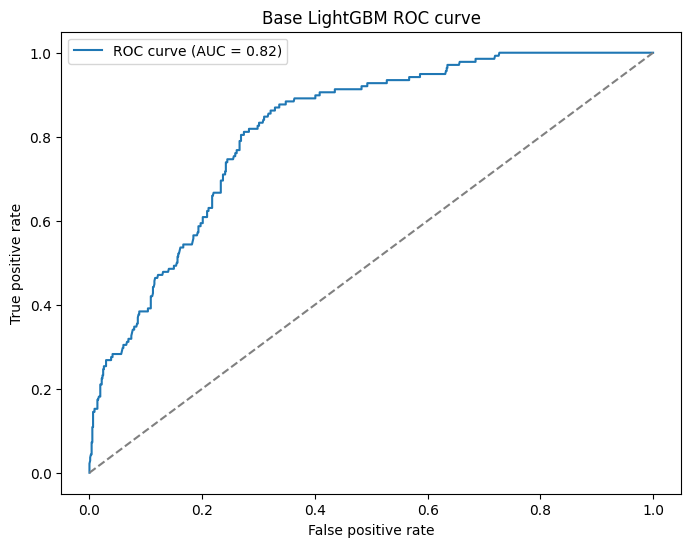

In [194]:
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('Base LightGBM ROC curve')
plt.legend()
plt.show()

<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

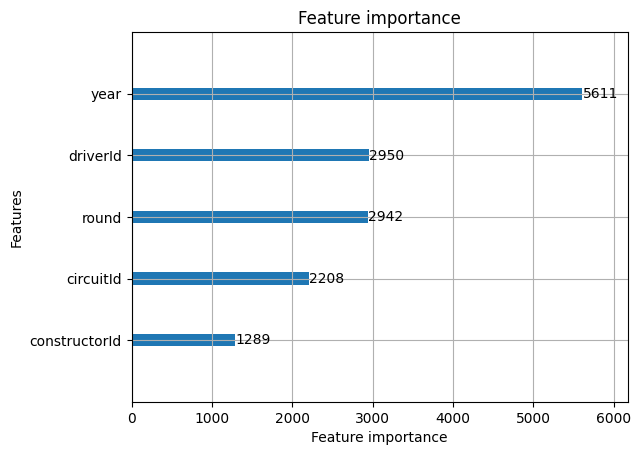

In [195]:
lgb.plot_importance(model)

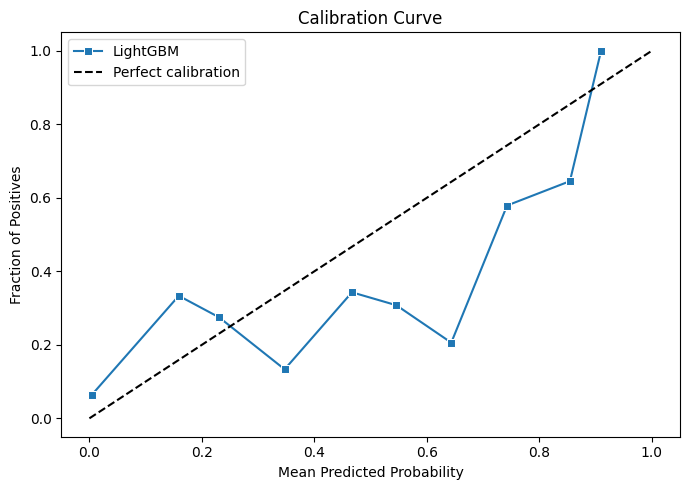

In [196]:
import seaborn as sns
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt
import pandas as pd

# --- Calibration Curve ---
fraction_of_positives, mean_predicted_value = calibration_curve(
    y_val, val_preds, n_bins=10
)

calib_df = pd.DataFrame({
    "Mean Predicted Probability": mean_predicted_value,
    "Fraction of Positives": fraction_of_positives
})

fig1, ax1 = plt.subplots(figsize=(7, 5))
sns.lineplot(
    data=calib_df,
    x="Mean Predicted Probability",
    y="Fraction of Positives",
    marker="s", label="LightGBM", ax=ax1
)
ax1.plot([0, 1], [0, 1], "k--", label="Perfect calibration")
ax1.set_title("Calibration Curve")
ax1.legend()
plt.tight_layout()
plt.show()

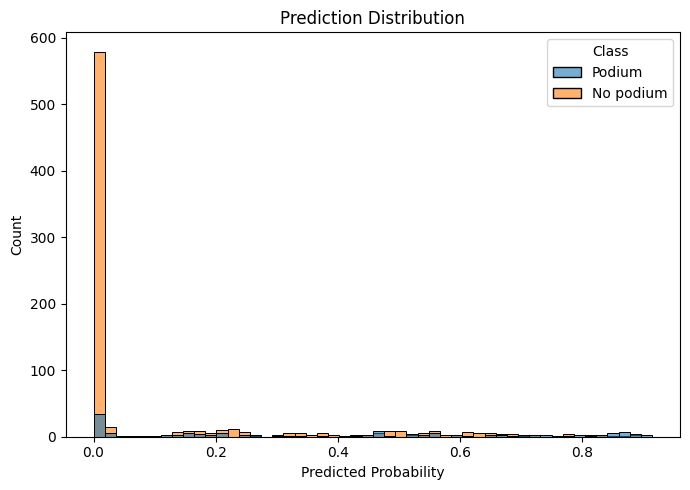

In [197]:
# --- Prediction Distribution ---
dist_df = pd.DataFrame({
    "Predicted Probability": val_preds,
    "Class": ["Podium" if y == 1 else "No podium" for y in y_val]
})

fig2, ax2 = plt.subplots(figsize=(7, 5))
sns.histplot(
    data=dist_df,
    x="Predicted Probability",
    hue="Class",
    bins=50,
    alpha=0.6,
    ax=ax2
)
ax2.set_title("Prediction Distribution")
plt.tight_layout()
plt.show()

Checking against the test set

In [198]:
print(model._Booster.pandas_categorical)

[]


In [199]:
test_race_data_df = full_race_data_df[full_race_data_df["year"] == 2025].copy()

for col in cat_features:
    test_race_data_df[col] = test_race_data_df[col].astype(float)

X_test = test_race_data_df[features]
y_test = test_race_data_df["podiumFinish"]

test_preds = model.predict_proba(X_test)[:, 1]

In [200]:
test_preds = model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, test_preds)
auc  = roc_auc_score(y_test, test_preds)
brier = brier_score_loss(y_test, test_preds)

print(f"AUC:   {auc:.4f}  (baseline: 0.79)")
print(f"Brier: {brier:.4f}  (baseline: 0.12)")

AUC:   0.5001  (baseline: 0.79)
Brier: 0.1502  (baseline: 0.12)


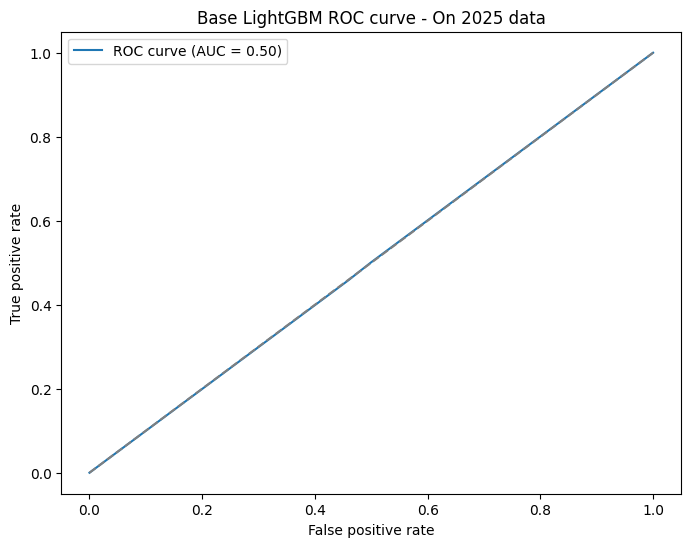

In [202]:
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('Base LightGBM ROC curve - On 2025 data')
plt.legend()
plt.show()